# Week 2A — Bourdet Derivative and Smoothing

## Task 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy.special import expi
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler

## Task 2 — Load the pressure-transient data

In [2]:
df = pd.read_csv("synthetic_well_test.csv")

time = df["Time_hr"].to_numpy()
dp = df["DeltaP_psi"].to_numpy()

ln_time = np.log(time)

df.head()

,Time_hr,tD,pD,DeltaP_psi,Pwf_psi
0,0.001000,70.320000,2.532843,85.833000,3914.167000
1,0.001123,78.992146,2.590795,87.796852,3912.203148
2,0.001262,88.733776,2.648767,89.761429,3910.238571
3,0.001417,99.676783,2.706759,91.726649,3908.273351
4,0.001592,111.969326,2.764768,93.692444,3906.307556


## Task 3 — Define the Bourdet derivative function

In [3]:
def bourdet_derivative(pressure, time):

    pressure = np.asarray(pressure)
    time = np.asarray(time)

    ln_time = np.log(time)

    derivative = np.full(
        len(pressure),
        np.nan
    )

    for i in range(1, len(pressure) - 1):

        dx_left = (
            ln_time[i]
            - ln_time[i - 1]
        )

        dx_right = (
            ln_time[i + 1]
            - ln_time[i]
        )

        slope_left = (
            pressure[i]
            - pressure[i - 1]
        ) / dx_left

        slope_right = (
            pressure[i + 1]
            - pressure[i]
        ) / dx_right

        derivative[i] = (
            slope_left
            * dx_right
            / (dx_left + dx_right)
            +
            slope_right
            * dx_left
            / (dx_left + dx_right)
        )

    return derivative

## Task 4 — Calculate the clean derivative

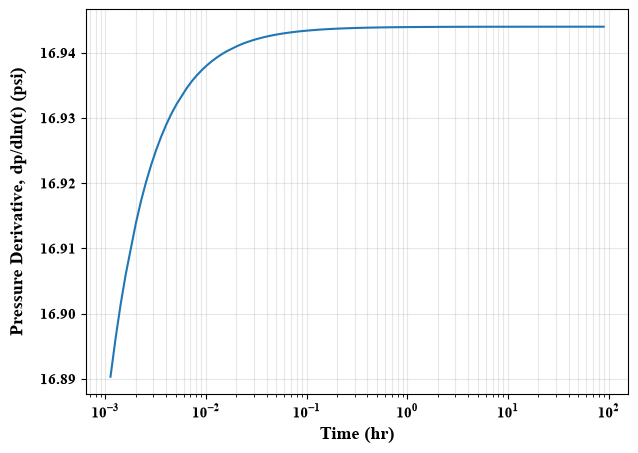

In [4]:
derivative_clean = bourdet_derivative(dp, time)

plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family
plt.semilogx(time, derivative_clean)
plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.savefig("Raw Bourdet Pressure Derivative.jpeg", dpi = 300)
plt.show()

## Task 5 — Add a transient peak to the derivative

In [5]:
A_peak = 10.0
t_peak = 1.0
sigma_t = 0.35

gaussian_peak = A_peak*np.exp(-((ln_time-np.log(t_peak))**2)/(2*sigma_t**2))
modified_derivative = bourdet_derivative(dp, time) + gaussian_peak

peak_idx = np.nanargmax(modified_derivative)

print("Peak time:", time[peak_idx])
print("Feature at peak:", gaussian_peak[peak_idx])
print("Modified derivative at peak:", modified_derivative[peak_idx])

#Trapezoidal Rule used for Integral to recover modified pressre drop data

modified_derivative[0] = modified_derivative[1]
modified_derivative[-1] = modified_derivative[-2]

modified_dp = np.zeros_like(dp)
modified_dp[0] = dp[0]
for i in range(1, len(dp)):
    modified_dp[i] = modified_dp[i-1] + (modified_derivative[i] + modified_derivative[i-1])*(ln_time[i]-ln_time[i-1])/2

pressure_offset = modified_dp - dp
print("Final pressure offset:", pressure_offset[-1])

Peak time: 0.9545484566618336
Feature at peak: 9.912069715033049
Modified derivative at peak: 26.856006465584016
Final pressure offset: 8.77330427582109


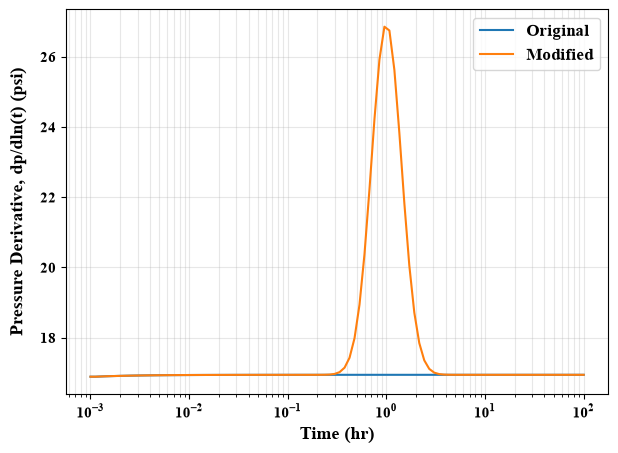

In [6]:
derivative_clean[0] = derivative_clean[1]
derivative_clean[-1] = derivative_clean[-2]

plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.semilogx(time, derivative_clean, label="Original")
plt.semilogx(time, modified_derivative, label="Modified")
plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.savefig("Raw and Modified Bourdet Pressure Derivative.jpeg", dpi = 300)
plt.show()

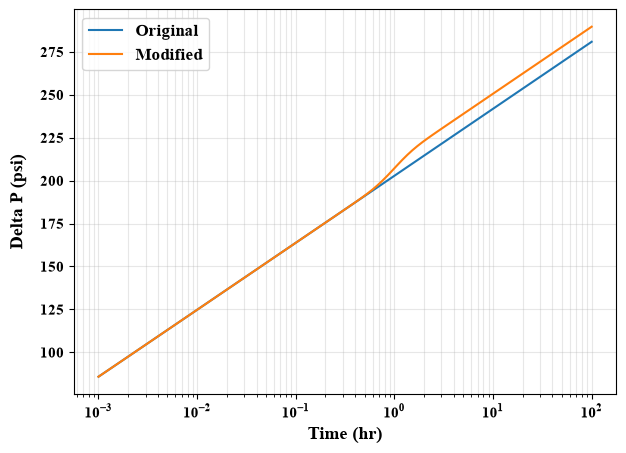

In [7]:
plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.semilogx(time, dp, label="Original")
plt.semilogx(time, modified_dp, label="Modified")
plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Delta P (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.savefig("Raw and Modified Pressure Drop.jpeg", dpi = 300)
plt.show()

## Task 6 — Add noise to demonstrate the derivative-noise problem

In [8]:
np.random.seed(42)
np.random.seed(42)

noise = np.random.normal(
    loc=0.0,
    scale=0.5,
    size=len(modified_dp)
)

noisy_modified_dp = modified_dp + noise

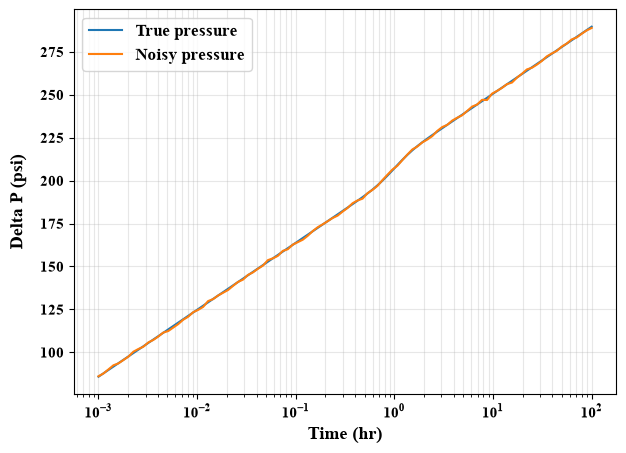

In [9]:
plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family


plt.semilogx(time, modified_dp, label="True pressure")
plt.semilogx(time, noisy_modified_dp, label="Noisy pressure")
plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Delta P (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.savefig("Noisy and Clean Modified Pressure Drop.jpeg", dpi = 300)
plt.show()

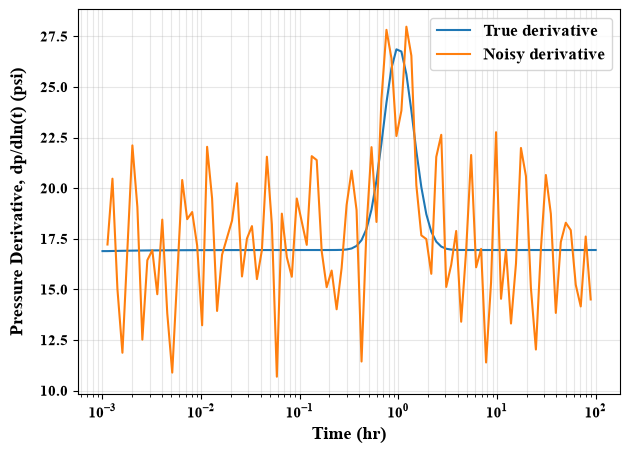

In [10]:
noisy_modified_derivative = bourdet_derivative(noisy_modified_dp, time)

plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.semilogx(time, modified_derivative, label="True derivative")
plt.semilogx(time, noisy_modified_derivative, label="Noisy derivative")

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.savefig("Noisy and Clean Modified Bourdet Pressure Derivative.jpeg", dpi = 300)
plt.show()

In [11]:
peak_idx_noisy = np.nanargmax(noisy_modified_derivative)

print("True peak:", np.nanmax(modified_derivative))

print("True peak time:", time[np.nanargmax(modified_derivative)])

print("Noisy maximum:", noisy_modified_derivative[peak_idx_noisy])

print("Noisy maximum time:", time[peak_idx_noisy])

True peak: 26.856006465584016
True peak time: 0.9545484566618336
Noisy maximum: 27.97351634775211
Noisy maximum time: 1.2045035402587825


## Task 7 — Smoothen with Savitzky-Golay and recalculate derivative

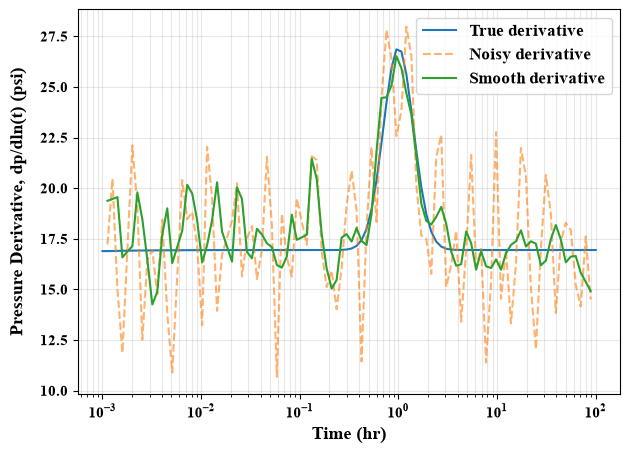

In [12]:
smoothed_modified_dp = savgol_filter(noisy_modified_dp, window_length=9, polyorder=2)
smoothed_modified_derivative = bourdet_derivative(smoothed_modified_dp, time)

plt.figure(figsize=(7, 5))
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.semilogx(time, modified_derivative, label="True derivative")
plt.semilogx(time, noisy_modified_derivative, alpha=0.6, linestyle = "--", label="Noisy derivative")
plt.semilogx(time, smoothed_modified_derivative, label="Smooth derivative")

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.savefig("Clean, Noisy and Smooth Modified Bourdet Pressure Derivative with window length = 9.jpeg", dpi = 300)
plt.show()

In [13]:
# Window sizes to compare
window_lengths = [5, 9, 15, 21]
polyorder = 2

smoothed_modified_pressure = {}
smoothed_modified_derivatives = {}
mae_modified_results = {}

for i in window_lengths:

    if i > len(noisy_modified_dp):
        continue

    if polyorder >= i:
        continue

    # Smooth noisy pressure
    smoothed_modified_dp = savgol_filter(
        noisy_modified_dp,
        window_length=i,
        polyorder=polyorder
    )

    # Derivative after smoothing
    smoothed_modified_derivative = bourdet_derivative(
        smoothed_modified_dp,
        time
    )

    valid_smoothed = (
        np.isfinite(modified_derivative)
        & np.isfinite(smoothed_modified_derivative)
    )

    mae = np.mean(
        np.abs(
            smoothed_modified_derivative[valid_smoothed]
            - modified_derivative[valid_smoothed]
        )
    )

    smoothed_modified_pressure[i] = smoothed_modified_dp
    smoothed_modified_derivatives[i] = smoothed_modified_derivative
    mae_modified_results[i] = mae

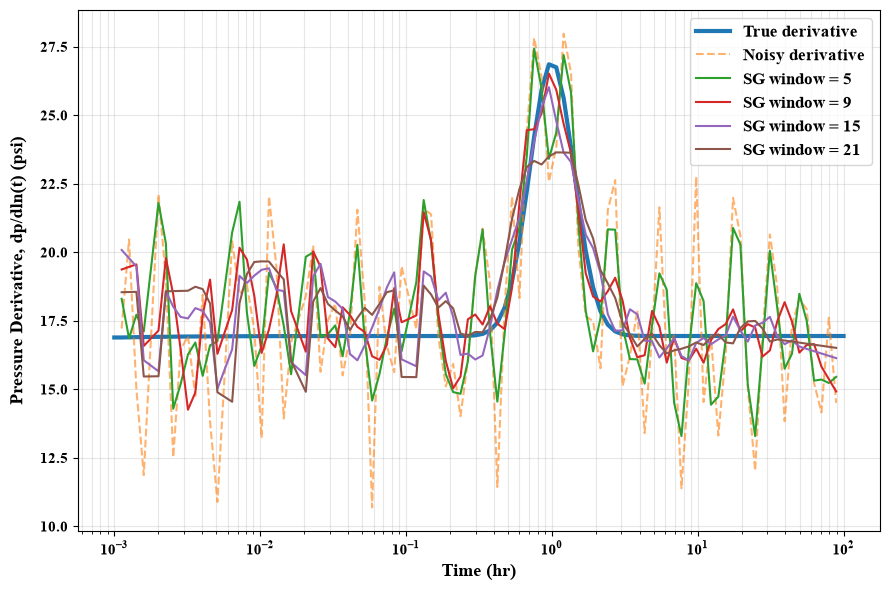

In [14]:
plt.figure(figsize=(9, 6))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

# True derivative containing the Gaussian transient
plt.semilogx(time, modified_derivative, linewidth=3, label="True derivative")

# Noisy derivative
plt.semilogx(time, noisy_modified_derivative, alpha=0.6, linestyle = "--", label="Noisy derivative")

# Smoothed derivatives
for i in window_lengths:

    if i not in smoothed_modified_derivatives:
        continue

    plt.semilogx(time, smoothed_modified_derivatives[i], label=f"SG window = {i}")

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.tight_layout()
plt.savefig("Clean, Noisy and Smooth Modified Bourdet Pressure Derivative with varying window lengths.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

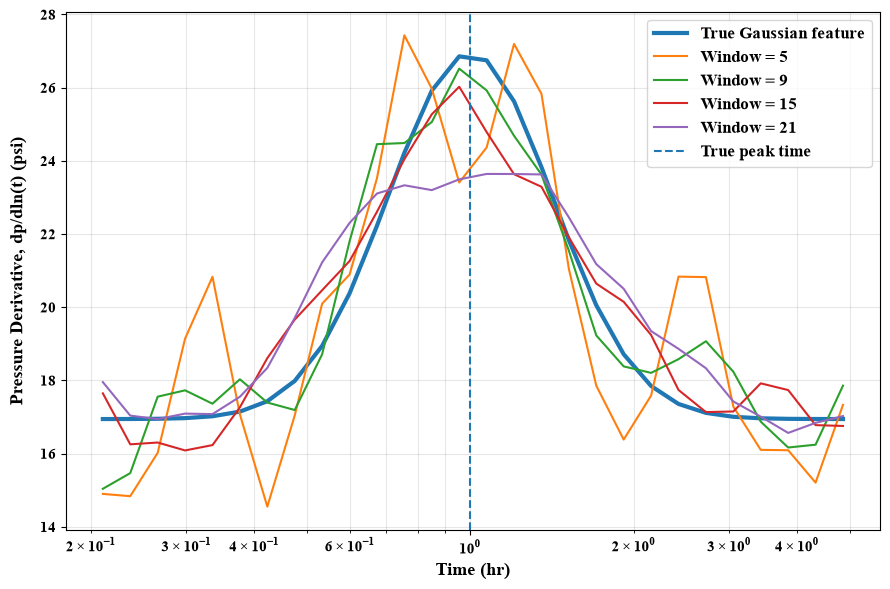

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

peak_mask = ((time >= t_peak / 5) & (time <= t_peak * 5))

# True derivative
ax.semilogx(time[peak_mask], modified_derivative[peak_mask], linewidth=3, label="True Gaussian feature")

# Filtered derivatives
for i in window_lengths:

    if i not in smoothed_modified_derivatives:
        continue

    deriv = smoothed_modified_derivatives[i]

    ax.semilogx(time[peak_mask], deriv[peak_mask], label=f"Window = {i}")

# True Gaussian peak location
ax.axvline(t_peak, linestyle="--", label="True peak time")

ax.set_xlabel("Time (hr)", fontname="Times New Roman", fontweight="bold", fontsize=13)

ax.set_ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname="Times New Roman", fontweight="bold", fontsize=13, labelpad=10)

# Apply font to ALL tick labels
for label in ax.get_xticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

for label in ax.get_yticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

ax.grid(True, which="both", alpha=0.3)

ax.legend(prop=FontProperties(family="Times New Roman", weight="bold", size=12))

fig.tight_layout()

fig.savefig("Peak Preservation by Filter Window.jpeg", dpi=300, bbox_inches="tight")

plt.show()

## Task 8 — MAE, Gaussian Peak error, Gaussian Peak-Time Error

In [16]:
peak_results = []

# Search only near the known Gaussian transient
peak_mask = (
    (time >= t_peak / 5)
    &
    (time <= t_peak * 5)
)

# True peak within that region
true_region = modified_derivative[peak_mask]
true_time_region = time[peak_mask]

true_idx = np.nanargmax(true_region)

true_peak_value = true_region[true_idx]
true_peak_time = true_time_region[true_idx]

for i in window_lengths:

    if i not in smoothed_modified_derivatives:
        continue

    deriv = smoothed_modified_derivatives[i]

    deriv_region = deriv[peak_mask]

    idx = np.nanargmax(deriv_region)

    recovered_peak = deriv_region[idx]
    recovered_time = true_time_region[idx]

    peak_results.append({
        "window": i,
        "MAE": mae_modified_results[i],
        "peak_height": recovered_peak,
        "peak_time": recovered_time,
        "peak_height_error": abs(
            recovered_peak - true_peak_value
        ),
        "log_peak_time_error": abs(
            np.log10(
                recovered_time
                / true_peak_time
            )
        )
    })

peak_results_df = pd.DataFrame(peak_results)

peak_results_df

,window,MAE,peak_height,peak_time,peak_height_error,log_peak_time_error
0,5,1.677673,27.430062,0.756463,0.574055,0.101010
1,9,1.059966,26.520019,0.954548,0.335987,0.000000
2,15,1.000366,26.024230,0.954548,0.831777,0.000000
3,21,1.092023,23.642316,1.072267,3.213690,0.050505


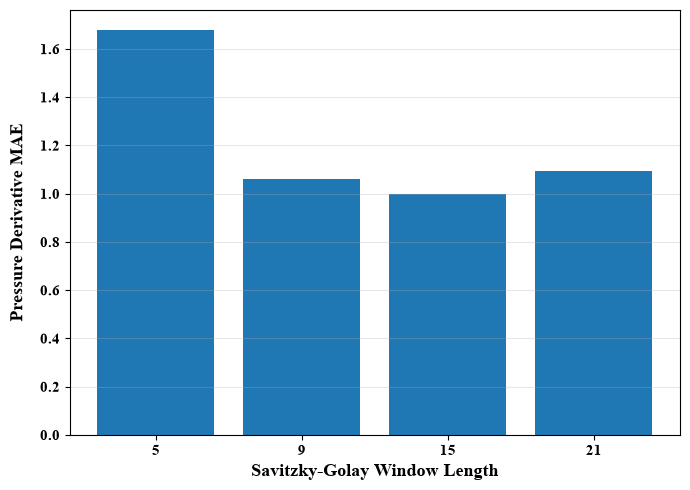

In [17]:
plt.figure(figsize=(7, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.bar(peak_results_df["window"].astype(str), peak_results_df["MAE"])

plt.xlabel("Savitzky-Golay Window Length", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative MAE", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)

plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Overall Pressure Derivative Error.jpeg", dpi = 300, bbox_inches="tight")
plt.show()


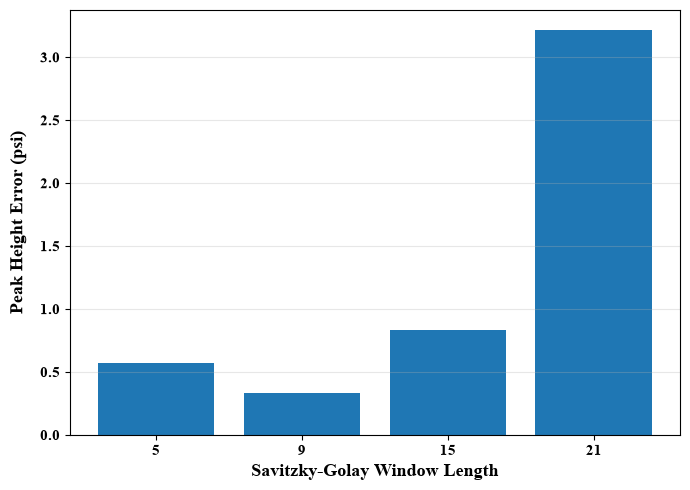

In [18]:
plt.figure(figsize=(7, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.bar(peak_results_df["window"].astype(str), peak_results_df["peak_height_error"])

plt.xlabel("Savitzky-Golay Window Length", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Peak Height Error (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Gaussian Peak Height Preservation.jpeg", dpi = 300, bbox_inches="tight")
plt.show()


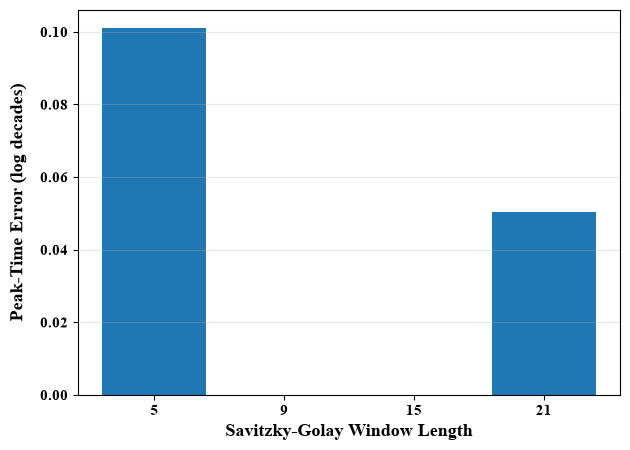

In [19]:
plt.figure(figsize=(7, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

plt.bar(peak_results_df["window"].astype(str), peak_results_df["log_peak_time_error"])

plt.xlabel("Savitzky-Golay Window Length", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Peak-Time Error (log decades)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("Gaussian Peak-Time Preservation.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

# Week 2B — Feature Engineering

## Task 9 — Reservoir/time settings

In [20]:
time_hr = np.logspace(-3, 2, 1000)

q = 500
μ = 1.0
B = 1.2
h = 50
ϕ = 0.20
ct = 1.5e-5
rw = 0.25

## Task 10 — Generate 500 parameter combinations

storage_samples and boundary_samples are synthetic controls used to create identifiable early- and late-time signatures. They are not being treated as rigorous physical wellbore-storage coefficient \(C\) or drainage radius \(r_e\).

In [21]:
np.random.seed(42)

n_cases = 500

k_samples = np.random.uniform(10, 150, n_cases)

skin_samples = np.random.uniform(-2, 15, n_cases)

storage_samples = np.random.uniform(0.3, 1.5, n_cases)

boundary_samples = np.random.uniform(5, 30, n_cases)

## Task 11 — Generate all 500 synthetic well tests

In [22]:
all_cases = []

for case_id in range(n_cases):

    k_case = k_samples[case_id]
    skin_case = skin_samples[case_id]
    storage_case = storage_samples[case_id]
    boundary_case = boundary_samples[case_id]

    # Dimensionless time
    tD_case = (0.0002637* k_case* time_hr/ (ϕ * μ * ct * rw**2))

    # Line-source dimensionless pressure
    pD_case = -0.5 * expi(-1 / (4 * tD_case))

    # Zero-skin line-source pressure drop
    delta_p_zero_skin = (141.2* q* μ* B/ (k_case * h)) * pD_case

    # Base pressure derivative
    base_derivative = np.gradient(delta_p_zero_skin, np.log(time_hr))

    # ---------------------------------
    # EARLY TIME: WBS
    # ---------------------------------

    t_wbs = (0.01* storage_case)

    radial_level = (70.6 * q * μ * B / (k_case * h))

    # Unit-slope early-time derivative
    wbs_derivative = (radial_level * time_hr / t_wbs)

    # Smooth transition: WBS -> radial
    derivative_after_wbs = (wbs_derivative * base_derivative / (wbs_derivative + base_derivative))

    # ---------------------------------
    # LATE TIME: boundary effect
    # ---------------------------------

    boundary_factor = (1 + (time_hr / boundary_case)**1.6)

    synthetic_derivative = (derivative_after_wbs * boundary_factor**0.3)

    # ---------------------------------
    # INTEGRATE DERIVATIVE -> PRESSURE
    # ---------------------------------
    
    ln_time = np.log(time_hr)
    
    # Integrate the engineered derivative with respect to ln(t)
    synthetic_pressure = np.zeros_like(time_hr)
    
    synthetic_pressure[0] = delta_p_zero_skin[0]
    
    for i in range(1, len(time_hr)):
        synthetic_pressure[i] = (synthetic_pressure[i - 1] + 0.5*(synthetic_derivative[i] + synthetic_derivative[i - 1]) * (ln_time[i]-ln_time[i - 1]))
    
    # Constant pressure shift caused by skin
    skin_shift = (141.2 * q * μ * B/(k_case * h)) * skin_case
    
    # Final pressure response
    delta_p_case = (synthetic_pressure + skin_shift)

    case_df = pd.DataFrame({
        "case_id": case_id,
        "k_mD": k_case,
        "skin": skin_case,
        "storage_control": storage_case,
        "boundary_time_hr": boundary_case,
        "Time_hr": time_hr,
        "DeltaP_psi": delta_p_case,
        "Derivative_psi": synthetic_derivative
    })

    all_cases.append(case_df)

synthetic_cases_df = pd.concat(all_cases, ignore_index=True)

print(synthetic_cases_df.shape)
synthetic_cases_df.head()

(500000, 8)


,case_id,k_mD,skin,storage_control,boundary_time_hr,Time_hr,DeltaP_psi,Derivative_psi
0,0,62.435617,9.868749,0.52216,17.977045,0.001000,339.563134,2.179987
1,0,62.435617,9.868749,0.52216,17.977045,0.001012,339.588379,2.201151
2,0,62.435617,9.868749,0.52216,17.977045,0.001023,339.613869,2.222486
3,0,62.435617,9.868749,0.52216,17.977045,0.001035,339.639605,2.243987
4,0,62.435617,9.868749,0.52216,17.977045,0.001047,339.665591,2.265654


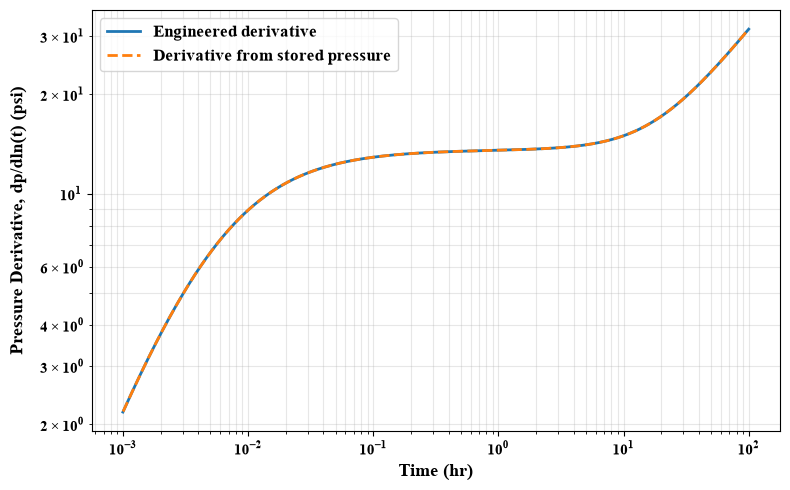

In [23]:
# ---------------------------------
# PRESSURE-DERIVATIVE CONSISTENCY CHECK
# ---------------------------------

# Select one case
check_case_id = 0

check_case = synthetic_cases_df[
    synthetic_cases_df["case_id"] == check_case_id
].copy()

t_check = check_case["Time_hr"].values
p_check = check_case["DeltaP_psi"].values
stored_derivative = check_case["Derivative_psi"].values

# Recalculate derivative directly from stored pressure
pressure_derivative = np.gradient(p_check, np.log(t_check))

# Compare
fig, ax = plt.subplots(figsize=(8, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

ax.loglog(t_check, stored_derivative, label="Engineered derivative", linewidth=2)

ax.loglog(t_check, pressure_derivative, "--", label="Derivative from stored pressure", linewidth=2)

ax.set_xlabel("Time (hr)", fontname="Times New Roman", fontweight="bold", fontsize=13)

ax.set_ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname="Times New Roman", fontweight="bold", fontsize=13, labelpad=10)

# Apply font to ALL tick labels
for label in ax.get_xticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

for label in ax.get_yticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

ax.grid(True, which="both", alpha=0.3)

ax.legend(prop=FontProperties(family="Times New Roman", weight="bold", size=12))

fig.tight_layout()
plt.savefig(f"Pressure Derivative Consistency Check_Case {check_case_id}.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

## Task 12 — Function for finding continuous flow-regime blocks

In [24]:
def find_blocks(candidate):

    candidate = np.asarray(candidate, dtype=bool)

    changes = np.diff(candidate.astype(int))

    starts = list(np.where(changes == 1)[0] + 1)

    ends = list(np.where(changes == -1)[0])

    if candidate[0]:
        starts = [0] + starts

    if candidate[-1]:
        ends = ends + [len(candidate) - 1]

    return list(zip(starts, ends))

## Task 13 — Main feature-extraction function

In [25]:
def extract_features(time, derivative):

    time = np.asarray(time)
    derivative = np.asarray(derivative)

    # Local derivative slope on log-log coordinates
    local_slope = np.gradient(np.log10(derivative), np.log10(time))

    features = {}

    # =================================
    # 1. EARLY TIME — WBS
    # =================================

    wbs_candidate = (np.abs(local_slope - 1) < 0.25)

    wbs_blocks = find_blocks(wbs_candidate)

    features["wbs_detected"] = int(len(wbs_blocks) > 0)

    if wbs_blocks:

        s, e = wbs_blocks[0]

        features["wbs_slope"] = np.median(
            local_slope[s:e + 1]
        )

        features[
            "wbs_duration_decades"
        ] = np.log10(
            time[e] / time[s]
        )

    else:

        features["wbs_slope"] = np.nan
        features[
            "wbs_duration_decades"
        ] = np.nan


    # =================================
    # 2. MIDDLE TIME — RADIAL FLOW
    # =================================

    radial_candidate = (
        np.abs(local_slope)
        < 0.1
    )

    radial_blocks = find_blocks(
        radial_candidate
    )

    features["radial_detected"] = int(
        len(radial_blocks) > 0
    )

    if radial_blocks:

        s, e = radial_blocks[0]

        features[
            "radial_plateau_psi"
        ] = np.median(
            derivative[s:e + 1]
        )

        features[
            "radial_slope"
        ] = np.median(
            local_slope[s:e + 1]
        )

        features[
            "radial_start_hr"
        ] = time[s]

        features[
            "radial_duration_decades"
        ] = np.log10(
            time[e] / time[s]
        )

        radial_end = time[e]

    else:

        features[
            "radial_plateau_psi"
        ] = np.nan

        features[
            "radial_slope"
        ] = np.nan

        features[
            "radial_start_hr"
        ] = np.nan

        features[
            "radial_duration_decades"
        ] = np.nan

        radial_end = np.nan


    # =================================
    # 3. LATE TIME — BOUNDARY
    # =================================

    if features["radial_detected"]:

        boundary_candidate = (
            (time > radial_end)
            &
            (local_slope > 0.1)
        )

        boundary_blocks = find_blocks(
            boundary_candidate
        )

    else:

        boundary_blocks = []


    features[
        "boundary_detected"
    ] = int(
        len(boundary_blocks) > 0
    )


    # Maximum observed late-time derivative
    if np.isfinite(radial_end):

        late_mask = (
            time > radial_end
        )

    else:

        late_mask = np.zeros(
            len(time),
            dtype=bool
        )


    if np.any(late_mask):

        features[
            "boundary_peak_psi"
        ] = np.max(
            derivative[late_mask]
        )

    else:

        features[
            "boundary_peak_psi"
        ] = np.nan


    if boundary_blocks:

        s, e = boundary_blocks[0]

        features[
            "log_boundary_start_time"
        ] = np.log10(
            time[s]
        )

        features[
            "boundary_slope"
        ] = np.median(
            local_slope[s:e + 1]
        )

        features[
            "boundary_duration_decades"
        ] = np.log10(
            time[e] / time[s]
        )

    else:

        features[
            "log_boundary_start_time"
        ] = np.nan

        features[
            "boundary_slope"
        ] = np.nan

        features[
            "boundary_duration_decades"
        ] = np.nan

    return features

## Task 14 — Extract one feature row per case

In [26]:
feature_rows = []

for case_id, case in synthetic_cases_df.groupby(
    "case_id"
):

    time = case[
        "Time_hr"
    ].to_numpy()

    derivative = case[
        "Derivative_psi"
    ].to_numpy()

    features = extract_features(
        time,
        derivative
    )

    features["case_id"] = case_id

    features["k_mD"] = (
        case["k_mD"].iloc[0]
    )

    features["skin"] = (
        case["skin"].iloc[0]
    )

    features["storage_control"] = (
        case[
            "storage_control"
        ].iloc[0]
    )

    features[
        "boundary_time_hr_true"
    ] = case[
        "boundary_time_hr"
    ].iloc[0]

    feature_rows.append(
        features
    )


feature_dataset = pd.DataFrame(
    feature_rows
)

print(feature_dataset.shape)
feature_dataset.head()

(500, 18)


,wbs_detected,wbs_slope,wbs_duration_decades,radial_detected,radial_plateau_psi,radial_slope,radial_start_hr,radial_duration_decades,boundary_detected,boundary_peak_psi,log_boundary_start_time,boundary_slope,boundary_duration_decades,case_id,k_mD,skin,storage_control,boundary_time_hr_true
0,1,0.798469,0.240240,1,13.471068,0.024393,0.047498,2.212212,1,31.504552,0.893894,0.321784,1.106106,0,62.435617,9.868749,0.522160,17.977045
1,1,0.842305,0.500501,1,5.862940,0.030152,0.086484,1.921922,1,14.104569,0.863864,0.325748,1.136136,1,143.100003,7.113638,0.950281,16.979547
2,1,0.864349,0.650651,1,7.398578,0.049570,0.123621,1.276276,1,30.026551,0.373373,0.400495,1.626627,2,112.479152,3.261969,1.347535,5.641052
3,1,0.856581,0.590591,1,8.924347,0.034910,0.106421,1.731732,1,23.869217,0.763764,0.344003,1.236236,3,93.812188,11.834515,1.178670,13.531196
4,1,0.860574,0.625626,1,26.293568,0.034901,0.115362,1.726727,1,68.107958,0.793794,0.338501,1.206206,4,31.842610,9.640430,1.267873,14.504890


## Task 15 — Visualize Flow regimes and Sensitivity to Permeability and Skin with Pressure drop and Pressure derivative

In [27]:
np.random.seed(10)

selected_case_id = np.random.choice(
    synthetic_cases_df["case_id"].unique()
)

case = synthetic_cases_df[
    synthetic_cases_df["case_id"]
    == selected_case_id
].copy()

time_case = case["Time_hr"].to_numpy()
derivative_case = case["Derivative_psi"].to_numpy()

case_features = feature_dataset[
    feature_dataset["case_id"]
    == selected_case_id
].iloc[0]

print("Case ID:", selected_case_id)
print("k =", case["k_mD"].iloc[0], "mD")
print("Skin =", case["skin"].iloc[0])

Case ID: 265
k = 113.70760648558863 mD
Skin = 7.688124642812381


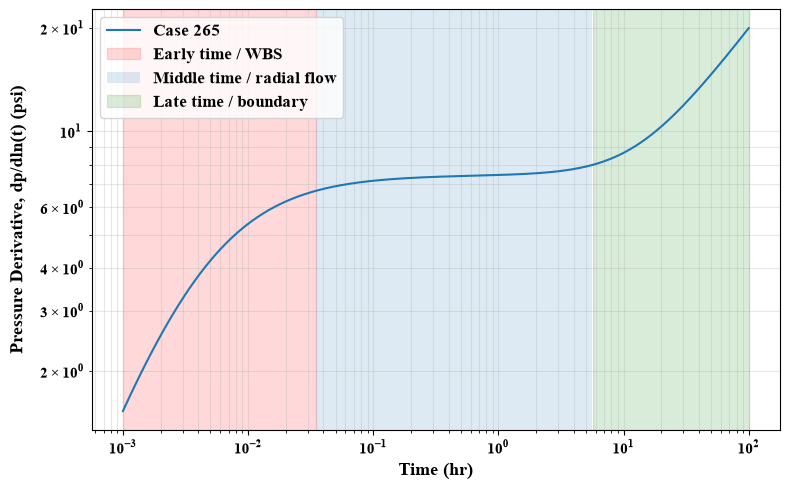

In [28]:
radial_start = case_features["radial_start_hr"]

radial_end = (radial_start* 10**case_features["radial_duration_decades"])

boundary_start = (10**case_features["log_boundary_start_time"])

fig, ax = plt.subplots(figsize=(8, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

ax.loglog(time_case, derivative_case, label=f"Case {selected_case_id}")

# WBS region
ax.axvspan(time_case[0], radial_start, alpha=0.15, label="Early time / WBS", color="red")

# Radial region
ax.axvspan(radial_start, radial_end, alpha=0.15, label="Middle time / radial flow")

# Boundary region
ax.axvspan(boundary_start, time_case[-1], alpha=0.15, label="Late time / boundary", color="green")

ax.set_xlabel("Time (hr)", fontname="Times New Roman", fontweight="bold", fontsize=13)

ax.set_ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname="Times New Roman", fontweight="bold", fontsize=13, labelpad=10)

# Apply font to ALL tick labels

for label in ax.get_xticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

for label in ax.get_yticklabels(which="both"):
    label.set_fontproperties(FontProperties(family="Times New Roman", weight="bold", size=11))

ax.grid(True, which="both", alpha=0.3)

ax.legend(prop=FontProperties(family="Times New Roman", weight="bold", size=12))

fig.tight_layout()
fig.savefig(f"Detected Flow Regimes for k = {case['k_mD'].iloc[0]:.1f} mD and Skin = {case['skin'].iloc[0]:.1f}.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

In [29]:
target_skin = feature_dataset["skin"].median()

skin_tolerance = 0.5

candidate_cases = feature_dataset[
    np.abs(
        feature_dataset["skin"]
        - target_skin
    ) < skin_tolerance
].copy()

candidate_cases = candidate_cases.sort_values(
    "k_mD"
)

indices = np.linspace(
    0,
    len(candidate_cases) - 1,
    5
).astype(int)

k_cases = candidate_cases.iloc[
    indices
]

print(
    k_cases[
        ["case_id", "k_mD", "skin"]
    ]
)

     case_id        k_mD      skin
334      334   16.440370  6.472252
135      135   55.248410  5.606010
212      212  101.274576  6.016795
308      308  121.326067  5.664269
499      499  148.069504  5.582098


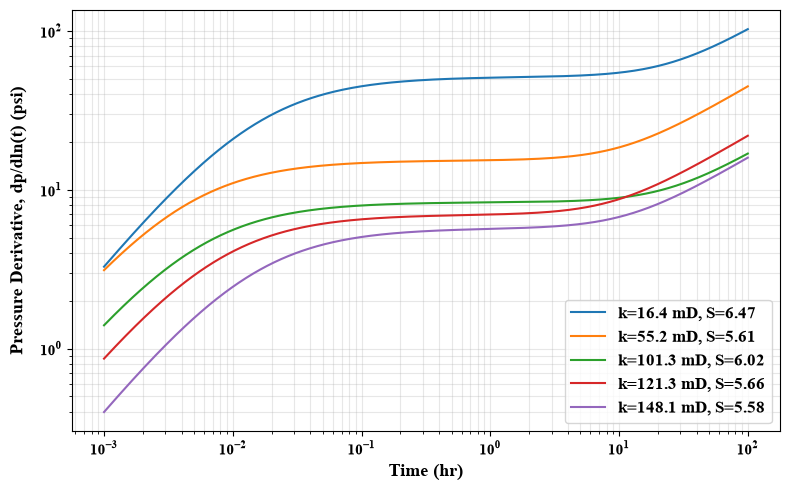

In [30]:
plt.figure(figsize=(8, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

for _, row in k_cases.iterrows():

    case_id = int(row["case_id"])

    case = synthetic_cases_df[
        synthetic_cases_df["case_id"]
        == case_id
    ]

    plt.loglog(
        case["Time_hr"],
        case["Derivative_psi"],
        label=(
            f"k={row['k_mD']:.1f} mD, "
            f"S={row['skin']:.2f}"
        )
    )

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.tight_layout()
plt.savefig("Pressure Derivative Sensitivity to Permeability.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

In [31]:
target_k = feature_dataset["k_mD"].median()

k_tolerance = 3.0

candidate_cases = feature_dataset[
    np.abs(
        feature_dataset["k_mD"]
        - target_k
    ) < k_tolerance
].copy()

candidate_cases = candidate_cases.sort_values(
    "skin"
)

indices = np.linspace(
    0,
    len(candidate_cases) - 1,
    5
).astype(int)

skin_cases = candidate_cases.iloc[
    indices
]

print(
    skin_cases[
        ["case_id", "k_mD", "skin"]
    ]
)

     case_id       k_mD       skin
474      474  83.878155  -1.469887
402      402  80.735332   1.084402
136      136  82.630687   7.054494
263      263  82.566151  10.647087
306      306  82.282049  13.884239


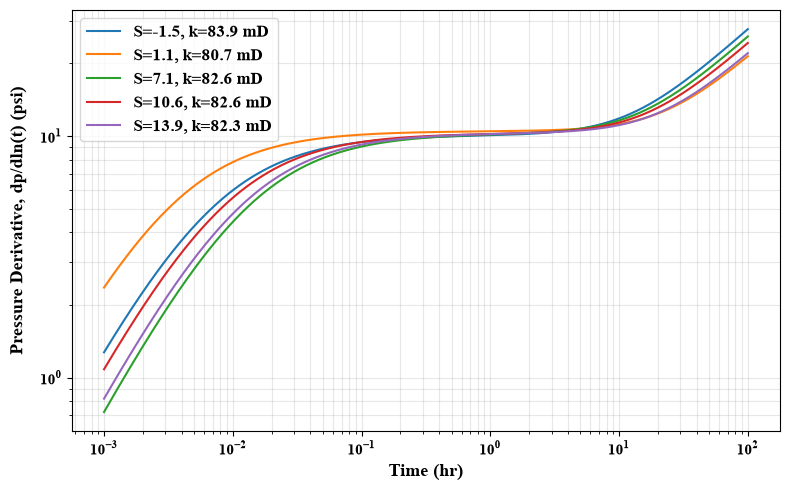

In [32]:
plt.figure(figsize=(8, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

for _, row in skin_cases.iterrows():

    case_id = int(row["case_id"])

    case = synthetic_cases_df[
        synthetic_cases_df["case_id"]
        == case_id
    ]

    plt.loglog(
        case["Time_hr"],
        case["Derivative_psi"],
        label=(
            f"S={row['skin']:.1f}, "
            f"k={row['k_mD']:.1f} mD"
        )
    )

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Derivative, dp/dln(t) (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.tight_layout()
plt.savefig("Pressure Derivative Sensitivity to Skin.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

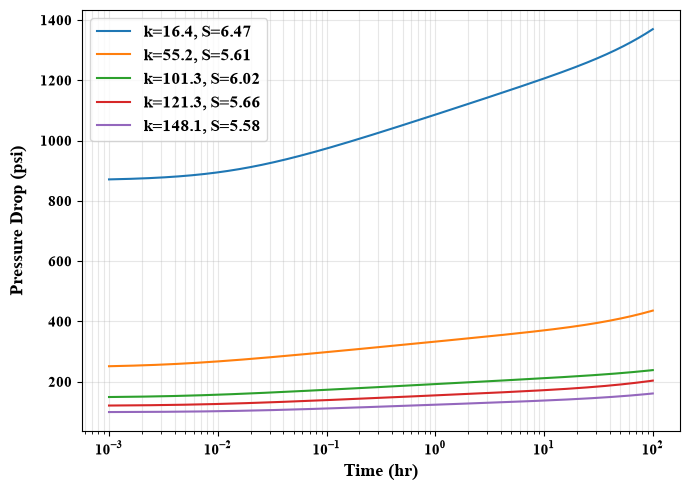

In [33]:
# ----------------------------
# Vary k, approximately fixed S
# ----------------------------

plt.figure(figsize=(7, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

for _, row in k_cases.iterrows():

    case_id = int(row["case_id"])

    case = synthetic_cases_df[
        synthetic_cases_df["case_id"]
        == case_id
    ]

    plt.semilogx(
        case["Time_hr"],
        case["DeltaP_psi"],
        label=(
            f"k={row['k_mD']:.1f}, "
            f"S={row['skin']:.2f}"
        )
    )

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Drop (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.tight_layout()
plt.savefig("Pressure Drop_Varying Permeability.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

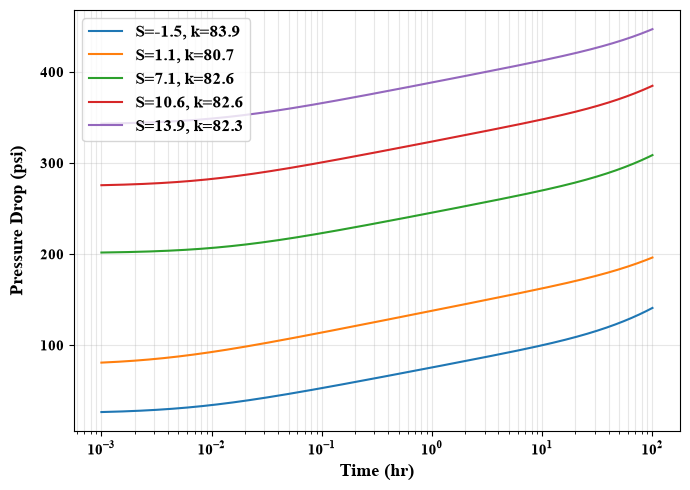

In [34]:
# ----------------------------
# Vary S, approximately fixed k
# ----------------------------

plt.figure(figsize=(7, 5))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family


for _, row in skin_cases.iterrows():

    case_id = int(row["case_id"])

    case = synthetic_cases_df[
        synthetic_cases_df["case_id"]
        == case_id
    ]

    plt.semilogx(
        case["Time_hr"],
        case["DeltaP_psi"],
        label=(
            f"S={row['skin']:.1f}, "
            f"k={row['k_mD']:.1f}"
        )
    )

plt.xlabel("Time (hr)", fontname= "Times New Roman", fontweight="bold", fontsize=13)
plt.ylabel("Pressure Drop (psi)", fontname= "Times New Roman", fontweight="bold", fontsize=13,labelpad=10)
plt.xticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.yticks(fontname= "Times New Roman", fontweight="bold", fontsize=11)
plt.grid(True, which="both", alpha=0.3)
plt.legend(prop = FontProperties(weight="bold", size=12))
plt.tight_layout()
plt.savefig("Pressure Drop_Varying Skin.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

## Task 16 — Add pressure information for skin

In [35]:
radial_pressure_rows = []

for case_id, case in synthetic_cases_df.groupby(
    "case_id"
):

    radial_start = feature_dataset.loc[
        feature_dataset["case_id"] == case_id,
        "radial_start_hr"
    ].iloc[0]

    radial_duration = feature_dataset.loc[
        feature_dataset["case_id"] == case_id,
        "radial_duration_decades"
    ].iloc[0]

    radial_end = (
        radial_start
        * 10**radial_duration
    )

    radial_mid_time = np.sqrt(
        radial_start
        * radial_end
    )

    time = case[
        "Time_hr"
    ].to_numpy()

    pressure = case[
        "DeltaP_psi"
    ].to_numpy()

    mid_idx = np.argmin(
        np.abs(
            np.log10(time)
            -
            np.log10(radial_mid_time)
        )
    )

    radial_pressure_rows.append(
        pressure[mid_idx]
    )


feature_dataset[
    "radial_mid_pressure_psi"
] = radial_pressure_rows

## Task 17 — Validate regime extraction

In [36]:
print(
    feature_dataset[
        [
            "wbs_detected",
            "radial_detected",
            "boundary_detected"
        ]
    ].sum()
)

print()

print(
    feature_dataset[
        [
            "storage_control",
            "wbs_duration_decades",
            "boundary_time_hr_true",
            "log_boundary_start_time"
        ]
    ].corr()
)

wbs_detected         500
radial_detected      500
boundary_detected    500
dtype: int64

                         storage_control  wbs_duration_decades  \
storage_control                 1.000000              0.981184   
wbs_duration_decades            0.981184              1.000000   
boundary_time_hr_true           0.005223              0.009794   
log_boundary_start_time        -0.020526             -0.015348   

                         boundary_time_hr_true  log_boundary_start_time  
storage_control                       0.005223                -0.020526  
wbs_duration_decades                  0.009794                -0.015348  
boundary_time_hr_true                 1.000000                 0.975925  
log_boundary_start_time               0.975925                 1.000000  


In [37]:
print(
    feature_dataset[
        [
            "k_mD",
            "skin",
            "radial_plateau_psi",
            "radial_mid_pressure_psi"
        ]
    ].corr()
)

                             k_mD      skin  radial_plateau_psi  \
k_mD                     1.000000  0.010354           -0.808932   
skin                     0.010354  1.000000           -0.021863   
radial_plateau_psi      -0.808932 -0.021863            1.000000   
radial_mid_pressure_psi -0.651308  0.438392            0.790157   

                         radial_mid_pressure_psi  
k_mD                                   -0.651308  
skin                                    0.438392  
radial_plateau_psi                      0.790157  
radial_mid_pressure_psi                 1.000000  


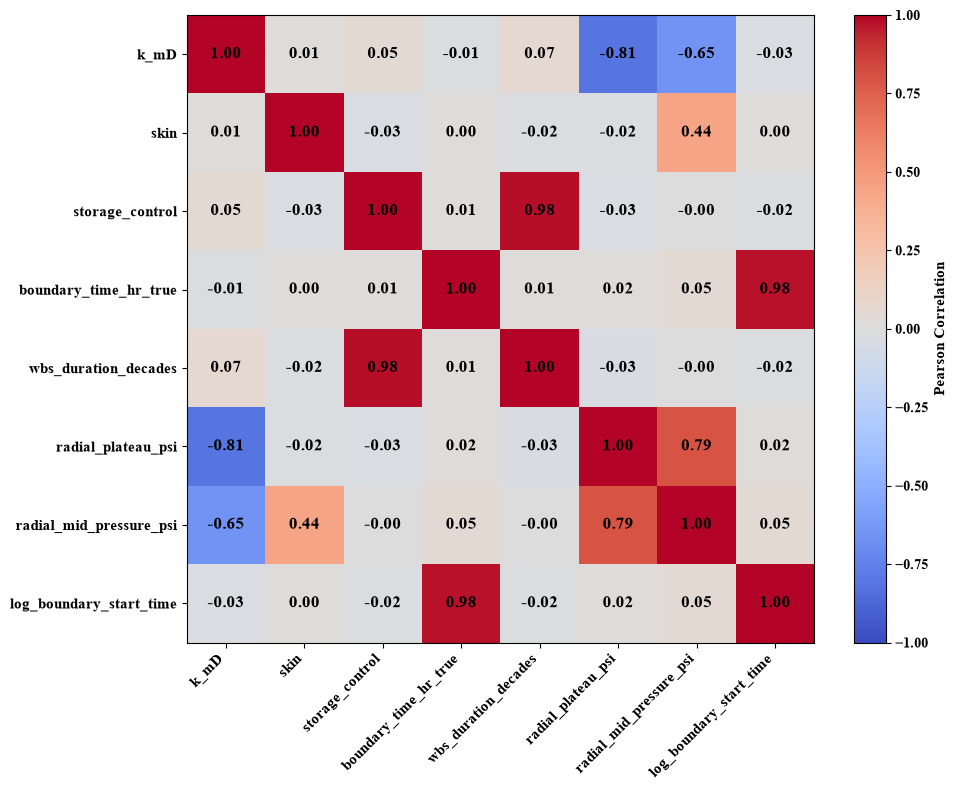

In [38]:
corr_columns = [
    "k_mD",
    "skin",
    "storage_control",
    "boundary_time_hr_true",
    "wbs_duration_decades",
    "radial_plateau_psi",
    "radial_mid_pressure_psi",
    "log_boundary_start_time"
]

# Correlation matrix
corr_matrix = feature_dataset[corr_columns].corr()

# Plotting Correlation matrix Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

# Axis labels
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))

ax.set_xticklabels(corr_columns, rotation=45, ha="right", fontname="Times New Roman", fontweight="bold", fontsize=11)

ax.set_yticklabels(corr_columns, fontname="Times New Roman", fontweight="bold", fontsize=11)

# Write correlation values inside cells
for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center", fontname="Times New Roman", fontweight="bold", fontsize=12
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(
    "Pearson Correlation",
    fontname="Times New Roman",
    fontweight="bold",
    fontsize=11
)

# Colorbar tickmark font
for label in cbar.ax.get_yticklabels():
    label.set_fontname("Times New Roman")
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.tight_layout()
fig.savefig("Correlation Matrix of Synthetic Controls and Extracted Features.jpeg", dpi = 300, bbox_inches="tight")
plt.show()

## Task 18 — Build final ML input and target tables

In [39]:
feature_columns = [

    # Early-time / WBS
    "wbs_slope",
    "wbs_duration_decades",

    # Middle-time / radial flow
    "radial_plateau_psi",
    "radial_slope",
    "radial_start_hr",
    "radial_duration_decades",
    "radial_mid_pressure_psi",

    # Late-time / boundary
    "boundary_peak_psi",
    "log_boundary_start_time",
    "boundary_slope",
    "boundary_duration_decades"
]


X = feature_dataset[
    feature_columns
].copy()


y = feature_dataset[
    [
        "k_mD",
        "skin"
    ]
].copy()


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "\nMissing values:"
)

print(
    X.isna().sum()
)

X shape: (500, 11)
y shape: (500, 2)

Missing values:
wbs_slope                    0
wbs_duration_decades         0
radial_plateau_psi           0
radial_slope                 0
radial_start_hr              0
radial_duration_decades      0
radial_mid_pressure_psi      0
boundary_peak_psi            0
log_boundary_start_time      0
boundary_slope               0
boundary_duration_decades    0
dtype: int64


## Task 19 — Standardize the features

In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(
    X_scaled.head()
)

print(
    "\nScaled feature statistics:"
)

print(
    X_scaled.describe()
)

   wbs_slope  wbs_duration_decades  radial_plateau_psi  radial_slope  \
0  -1.035175             -1.056876           -0.229491     -0.897072   
1   0.313892              0.281593           -0.728235     -0.054300   
2   0.992270              1.053788           -0.627568      2.787458   
3   0.753219              0.744910           -0.527547      0.642027   
4   0.876115              0.925089            0.611077      0.640706   

   radial_start_hr  radial_duration_decades  radial_mid_pressure_psi  \
0        -1.114274                 0.927611                 0.096398   
1         0.089000                -0.072713                -0.570807   
2         1.235194                -2.297572                -0.636620   
3         0.704329                -0.728098                -0.162851   
4         0.980283                -0.745345                 0.994400   

   boundary_peak_psi  log_boundary_start_time  boundary_slope  \
0          -0.285611                 0.297914       -0.209681   
1   